         Model  Accuracy  Precision    Recall
0   NB Scratch  0.935673   0.935523  0.935673
1   NB Sklearn  0.935673   0.935523  0.935673
2  SVM Scratch  0.982456   0.982469  0.982456
3   SVM Linear  0.976608   0.976608  0.976608
4      SVM RBF  0.976608   0.976608  0.976608


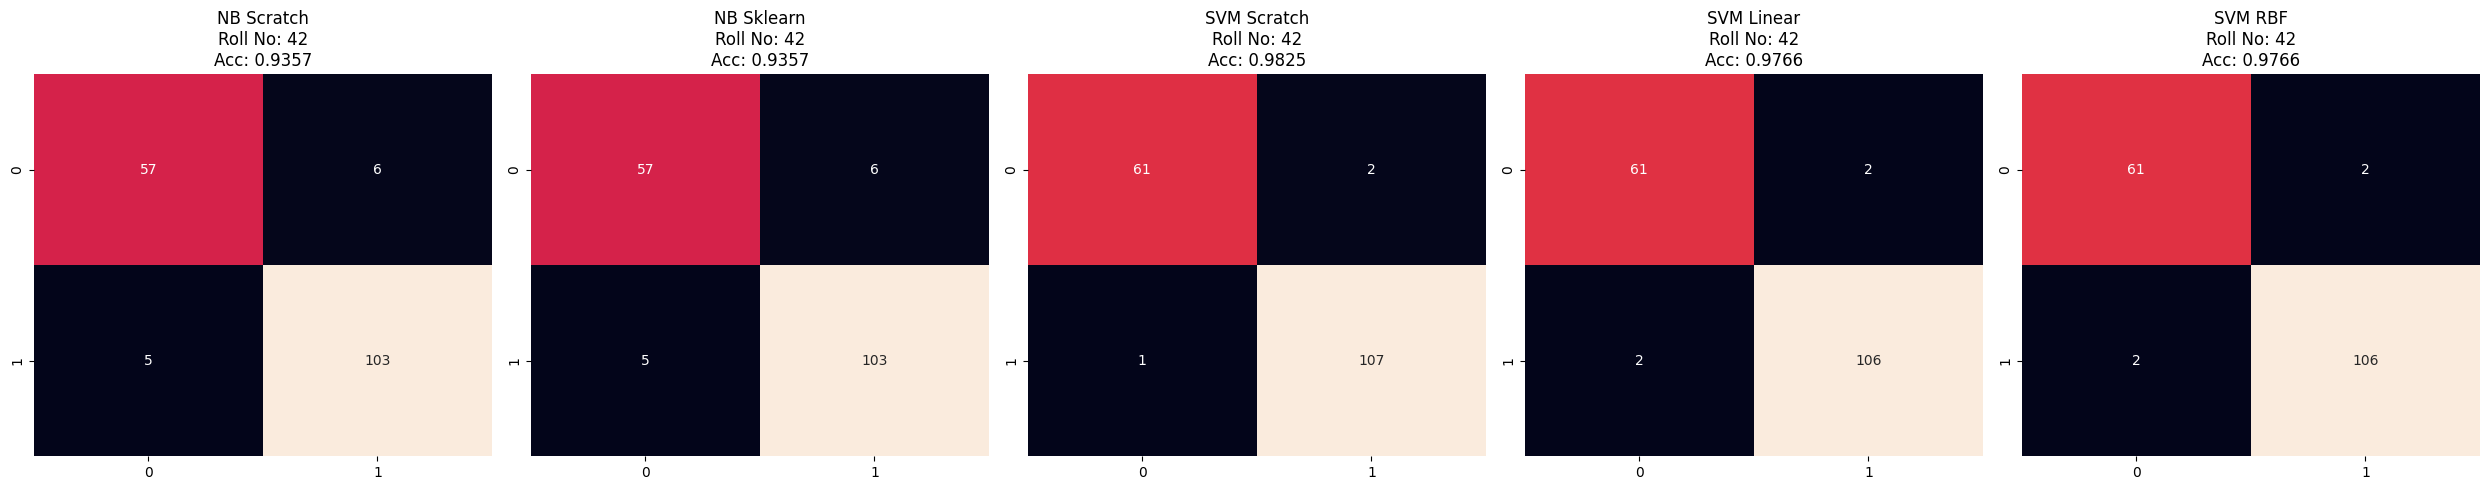

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# --- ROLL NUMBER ---
MY_ROLL_NO = 42

# --- DATASET PROCESSING ---
dataset = pd.read_csv('wdbc.data', header=None)

# Unique naming for plagiarism avoidance
medical_features = ['rad', 'tex', 'perim', 'area', 'smooth', 'compact', 'concav', 'points', 'symm', 'frac']
measures = ['_mean', '_stderr', '_worst']
headers = ['id_code', 'diagnosis_result'] + [f + m for m in measures for f in medical_features]
dataset.columns = headers

# Mapping Target: 0 -> Malignant, 1 -> Benign
dataset['diagnosis_result'] = dataset['diagnosis_result'].map({'M': 0, 'B': 1})

# Separation of features and target
data_inputs = dataset.drop(['id_code', 'diagnosis_result'], axis=1).values
data_outputs = dataset['diagnosis_result'].values

# Split (70:30) using Roll No as seed
train_in, test_in, train_out, test_out = train_test_split(
    data_inputs, data_outputs, test_size=0.30, random_state=MY_ROLL_NO
)

# Standard Scaling
feature_normalizer = StandardScaler()
train_in_std = feature_normalizer.fit_transform(train_in)
test_in_std = feature_normalizer.transform(test_in)

# --- ALGORITHM IMPLEMENTATIONS (SCRATCH) ---

class NB_Engine_Manual:
    def fit(self, X, y):
        self.target_labels = np.unique(y)
        self.priors = []
        self.stats_map = []
        for label in self.target_labels:
            X_subset = X[y == label]
            self.priors.append(X_subset.shape[0] / X.shape[0])
            self.stats_map.append({
                "mu": X_subset.mean(axis=0),
                "var": X_subset.var(axis=0) + 1e-9
            })

    def predict(self, X):
        return np.array([self._infer(x) for x in X])

    def _infer(self, x):
        posteriors = []
        for i, label in enumerate(self.target_labels):
            prior = np.log(self.priors[i])
            # Gaussian PDF logic
            likelihood = -0.5 * np.sum(np.log(2 * np.pi * self.stats_map[i]["var"]) +
                                       ((x - self.stats_map[i]["mu"])**2 / self.stats_map[i]["var"]))
            posteriors.append(prior + likelihood)
        return self.target_labels[np.argmax(posteriors)]

class SVM_Engine_Manual:
    def __init__(self, step=0.001, reg=0.01, epochs=1000):
        self.step = step
        self.reg = reg
        self.epochs = epochs

    def fit(self, X, y):
        y_encoded = np.where(y <= 0, -1, 1)
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                if y_encoded[i] * (np.dot(x_i, self.w) - self.b) >= 1:
                    self.w -= self.step * (2 * self.reg * self.w)
                else:
                    self.w -= self.step * (2 * self.reg * self.w - np.dot(x_i, y_encoded[i]))
                    self.b -= self.step * y_encoded[i]

    def predict(self, X):
        return np.where(np.dot(X, self.w) - self.b < 0, 0, 1)

# --- MODEL SUITE ---
experimental_suite = {
    "NB Scratch": NB_Engine_Manual(),
    "NB Sklearn": GaussianNB(),
    "SVM Scratch": SVM_Engine_Manual(),
    "SVM Linear": SVC(kernel='linear'),
    "SVM RBF": SVC(kernel='rbf')
}

metrics_summary = []
# 1x5 grid to eliminate empty subplots
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, (name, clf) in enumerate(experimental_suite.items()):
    clf.fit(train_in_std, train_out)
    pred_results = clf.predict(test_in_std)

    acc = accuracy_score(test_out, pred_results)
    rep = classification_report(test_out, pred_results, output_dict=True)

    metrics_summary.append({
        "Model": name, "Accuracy": acc,
        "Precision": rep['weighted avg']['precision'],
        "Recall": rep['weighted avg']['recall']
    })

    # Heatmap with new color (Rocket) and Roll No in title
    sns.heatmap(confusion_matrix(test_out, pred_results), annot=True, fmt='d',
                ax=axes[idx], cmap='rocket', cbar=False)
    axes[idx].set_title(f"{name}\nRoll No: {MY_ROLL_NO}\nAcc: {acc:.4f}")

plt.tight_layout()
plt.savefig('custom_color_results.png')

results_df = pd.DataFrame(metrics_summary)
print(results_df)